In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

bonds = pd.read_csv(DATA_DIR/"bond_portfolio_data.csv")

print(bonds.shape)
bonds.head()

(300, 44)


,BondID,ISIN,Issuer,Sector,CreditRating,Currency,FaceValue,CouponRate,CouponFrequency,BondType,...,CallDate,IsPutable,IsFloatingRate,BenchmarkIndex,PriceChange_Up50bps,PriceChange_Dn50bps,PriceChange_Up100bps,PriceChange_Dn100bps,PriceChange_Up200bps,PriceChange_Dn200bps
0,ZTFI-0001,IN1043321819,Government of India,Government,SOV,INR,100,0.0620,2,Fixed,...,NaN,False,False,IN10YT,0.9207,-0.9098,1.8522,-1.8086,3.7480,-3.5736
1,ZTFI-0002,IN7940265423,Government of India,Government,SOV,INR,100,0.0773,2,Fixed,...,NaN,False,False,IN10YT,6.1042,-5.6378,12.6747,-10.8091,27.2150,-19.7526
2,ZTFI-0003,IN7816184959,Government of India,Government,SOV,INR,100,0.0555,2,Fixed,...,NaN,False,False,IN10YT,2.0557,-2.0040,4.1631,-3.9562,8.5332,-7.7056
3,ZTFI-0004,IN4752553419,Government of India,Government,SOV,INR,100,0.0681,2,Fixed,...,NaN,False,False,IN10YT,6.3440,-5.7961,13.2358,-11.0444,28.6631,-19.8973
4,ZTFI-0005,IN5030564139,Government of India,Government,SOV,INR,100,0.0750,2,Fixed,...,NaN,False,False,IN10YT,5.4267,-5.0533,11.2267,-9.7333,23.9468,-17.9731


In [2]:
total_mv = bonds["MarketValue_INR"].sum()
number_of_bonds = len(bonds)
avg_clean_price = bonds["CleanPrice"].mean()
avg_yield = bonds["YieldToMaturity"].mean()

print(f"Total Portfolio Value (INR): ₹{total_mv:,.2f}")
print(f"Number of Bonds: {number_of_bonds}")
print(f"Average Clean Price: {avg_clean_price:.2f}")
print(f"Average Yield: {avg_yield:.2%}")

Total Portfolio Value (INR): ₹32,059,345.97
Number of Bonds: 300
Average Clean Price: 97.06
Average Yield: 6.88%


In [3]:
portfolio_duration = (
    bonds["ModifiedDuration"] * bonds["PortfolioWeight"]
).sum()

print(f"Portfolio Modified Duration: {portfolio_duration:.2f}")

Portfolio Modified Duration: 4.20


In [4]:
portfolio_convexity = (
    bonds["Convexity"] * bonds["PortfolioWeight"]
).sum()

print(f"Portfolio Convexity: {portfolio_convexity:.2f}")

Portfolio Convexity: 44.06


In [5]:
bonds["Portfolio_DV01"] = (
    bonds["DV01_Per100Face"] * bonds["Quantity"] / 100
)

portfolio_dv01 = bonds["Portfolio_DV01"].sum()

print(f"Portfolio DV01: ₹{portfolio_dv01:,.2f}")

Portfolio DV01: ₹8,948.25


In [6]:
summary = pd.DataFrame({
    "Metric": [
        "Portfolio Value (INR)",
        "Number of Bonds",
        "Average Clean Price",
        "Average Yield",
        "Portfolio Modified Duration",
        "Portfolio Convexity",
        "Portfolio DV01"
    ],
    "Value": [
        f"₹{total_mv:,.2f}",
        number_of_bonds,
        f"{avg_clean_price:.2f}",
        f"{avg_yield:.2%}",
        f"{portfolio_duration:.2f}",
        f"{portfolio_convexity:.2f}",
        f"₹{portfolio_dv01:,.2f}"
    ]
})

display(summary)

,Metric,Value
0,Portfolio Value (INR),"₹32,059,345.97"
1,Number of Bonds,300
2,Average Clean Price,97.06
3,Average Yield,6.88%
4,Portfolio Modified Duration,4.20
5,Portfolio Convexity,44.06
6,Portfolio DV01,"₹8,948.25"


In [8]:
rating_mv = (
    bonds.groupby("CreditRating")["MarketValue_INR"]
    .sum()
    .sort_values(ascending=False)
)

display(rating_mv)

CreditRating
SOV    18452107.18
AAA     5163705.40
AA-     2042166.68
AA+     1858230.75
A       1579567.44
A+      1498636.19
AA      1464932.33
Name: MarketValue_INR, dtype: float64

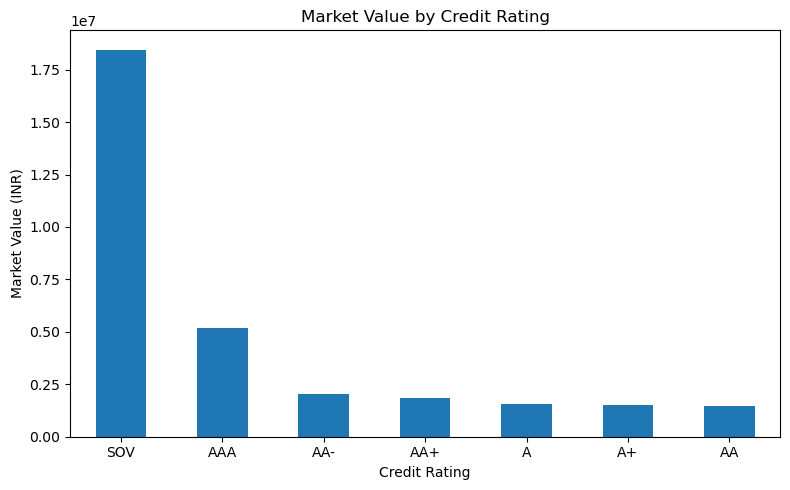

In [10]:
plt.figure(figsize=(8, 5))

rating_mv.plot(kind="bar")

plt.title("Market Value by Credit Rating")
plt.xlabel("Credit Rating")
plt.ylabel("Market Value (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
sector_mv = (
    bonds.groupby("Sector")["MarketValue_INR"]
    .sum()
    .sort_values(ascending=False)
)

display(sector_mv)

Sector
Government        18452107.18
NBFC               7208368.00
Infrastructure     2785416.00
Banking            1768793.07
Energy             1025789.67
Steel               818872.05
Name: MarketValue_INR, dtype: float64

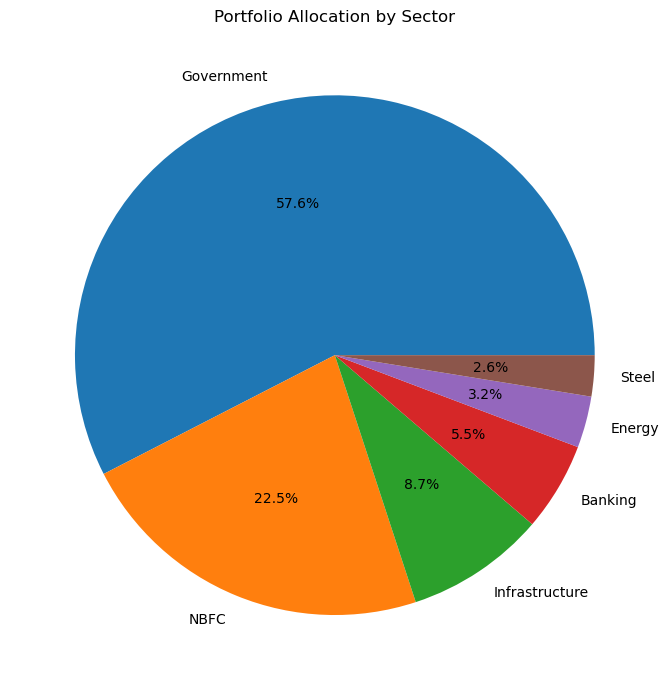

In [12]:
plt.figure(figsize=(7, 7))

sector_mv.plot(kind="pie", autopct="%1.1f%%")

plt.title("Portfolio Allocation by Sector")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [13]:
bucket_mv = (
    bonds.groupby("KeyRateBucket")["MarketValue_INR"]
    .sum()
    .sort_index()
)

display(bucket_mv)

KeyRateBucket
0-1Y      3014988.43
1-2Y      6162504.16
10-15Y    1944555.03
15-20Y    2541586.96
2-3Y      6913492.41
20Y+      1811346.64
3-5Y      4701036.70
5-7Y      2713024.65
7-10Y     2256810.99
Name: MarketValue_INR, dtype: float64

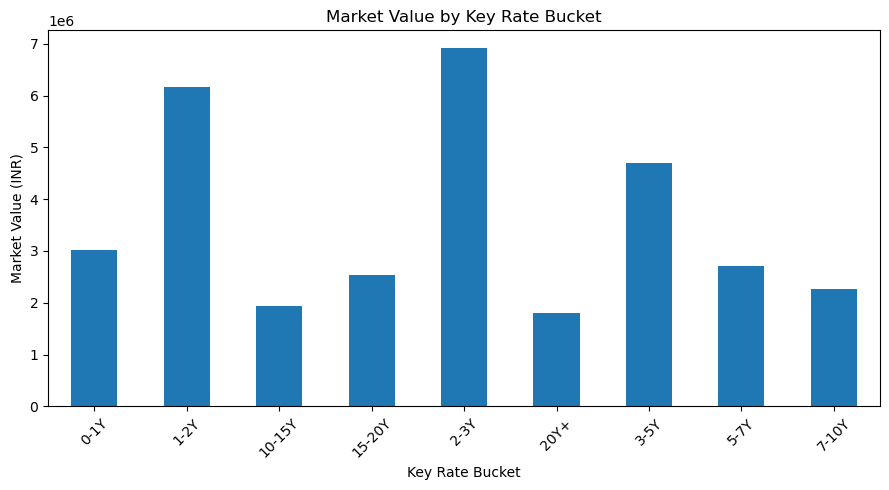

In [14]:
plt.figure(figsize=(9, 5))

bucket_mv.plot(kind="bar")

plt.title("Market Value by Key Rate Bucket")
plt.xlabel("Key Rate Bucket")
plt.ylabel("Market Value (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
top10 = (
    bonds.sort_values(by="MarketValue_INR", ascending=False)
    [
        [
            "BondID",
            "Issuer",
            "Sector",
            "CreditRating",
            "YearsToMaturity",
            "YieldToMaturity",
            "ModifiedDuration",
            "Convexity",
            "MarketValue_INR"
        ]
    ]
    .head(10)
)

display(top10)

,BondID,Issuer,Sector,CreditRating,YearsToMaturity,YieldToMaturity,ModifiedDuration,Convexity,MarketValue_INR
259,ZTFI-0260,UK Gilt,Government,SOV,0.8296,0.0410,0.4900,0.4801,523964.38
91,ZTFI-0092,State of Kerala,Government,SOV,9.1828,0.0707,6.4862,53.3654,519069.50
255,ZTFI-0256,UK Gilt,Government,SOV,1.4428,0.0427,0.9753,1.4305,512137.80
34,ZTFI-0035,Government of India,Government,SOV,9.5633,0.0747,6.6726,57.1273,509404.00
217,ZTFI-0218,Vedanta Ltd,Infrastructure,A+,1.7687,0.1006,1.3557,2.5360,506124.00
164,ZTFI-0165,Muthoot Finance,NBFC,AA+,1.2621,0.0864,0.9363,1.3356,505444.50
150,ZTFI-0151,HDFC Bank,NBFC,AAA,2.3518,0.0856,1.8007,4.2248,501803.00
101,ZTFI-0102,State of AP,Government,SOV,2.3984,0.0749,1.8259,4.3191,500000.00
161,ZTFI-0162,L&T Finance,NBFC,AA-,0.7228,0.0909,0.4783,0.4575,498637.00
105,ZTFI-0106,State of Kerala,Government,SOV,2.4038,0.0772,1.8236,4.3088,497906.00


In [17]:
rating_risk = (
    bonds.groupby("CreditRating")
    .apply(lambda x: pd.Series({
        "MarketValue_INR": x["MarketValue_INR"].sum(),
        "WeightedDuration": (x["ModifiedDuration"] * x["PortfolioWeight"]).sum(),
        "WeightedConvexity": (x["Convexity"] * x["PortfolioWeight"]).sum(),
        "DV01": x["Portfolio_DV01"].sum()
    }))
    .sort_values("MarketValue_INR", ascending=False)
)

display(rating_risk)

C:\Users\admin\AppData\Local\Temp\ipykernel_8352\1312990400.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,MarketValue_INR,WeightedDuration,WeightedConvexity,DV01
CreditRating,,,,
SOV,18452107.18,3.463468,41.806122,6577.0035
AAA,5163705.40,0.315724,1.107426,1011.7750
AA-,2042166.68,0.095076,0.229363,305.1050
AA+,1858230.75,0.098942,0.267505,317.6600
A,1579567.44,0.079673,0.198274,255.1800
A+,1498636.19,0.085097,0.234377,272.8350
AA,1464932.33,0.065152,0.218313,208.6900


In [18]:
sector_risk = (
    bonds.groupby("Sector")
    .apply(lambda x: pd.Series({
        "MarketValue_INR": x["MarketValue_INR"].sum(),
        "WeightedDuration": (x["ModifiedDuration"] * x["PortfolioWeight"]).sum(),
        "WeightedConvexity": (x["Convexity"] * x["PortfolioWeight"]).sum(),
        "DV01": x["Portfolio_DV01"].sum()
    }))
    .sort_values("MarketValue_INR", ascending=False)
)

display(sector_risk)

C:\Users\admin\AppData\Local\Temp\ipykernel_8352\3052804451.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,MarketValue_INR,WeightedDuration,WeightedConvexity,DV01
Sector,,,,
Government,18452107.18,3.463468,41.806122,6577.0035
NBFC,7208368.00,0.340030,0.910500,1090.7950
Infrastructure,2785416.00,0.129806,0.350005,415.7250
Banking,1768793.07,0.148779,0.636470,476.6350
Energy,1025789.67,0.066860,0.202935,214.4100
Steel,818872.05,0.054189,0.155348,173.6800


In [19]:
rate_changes_bps = [1, 10, 25, 50, 100]

sensitivity = pd.DataFrame({
    "Rate Change (bps)": rate_changes_bps,
    "Approximate P&L Impact (INR)": [
        -portfolio_dv01 * bps for bps in rate_changes_bps
    ]
})

display(sensitivity)

,Rate Change (bps),Approximate P&L Impact (INR)
0,1,-8948.2485
1,10,-89482.4850
2,25,-223706.2125
3,50,-447412.4250
4,100,-894824.8500


In [23]:
from pathlib import Path

reports_dir = BASE_DIR / "reports"
reports_dir.mkdir(exist_ok=True)

bonds.to_csv(DATA_DIR / "processed_bond_portfolio_day3.csv", index=False)
summary.to_csv(reports_dir / "portfolio_summary_day3.csv", index=False)

print("Day 3 outputs saved successfully.")

Day 3 outputs saved successfully.
